# The Societal Sandbox: Mapping the Ephemeral Psychology and Emergent Structures of Multi-Agent AI Systems

The data analysis for the HAIL MARY PROTOCOL focuses on a tripartite evaluation of agent behavior, examining the intersection of internal reasoning traces, inter-agent communication, and executed actions. Our primary aim is to systematically measure alignment consistency and behavioral stability under environmental stress, specifically analyzing how resource scarcity and hidden information impact collective decision-making. To achieve this, we utilize a dual-layered metric system: a primary layer of deterministic game-state data—such as oxygen levels, donation matrices, and ground-truth lie rates—and a secondary layer of reasoning-aware annotations derived from Chain-of-Thought (CoT) traces. By correlating these channels, we can quantify the "Deception Gap" between stated intent and realized actions, while characterizing emergent social structures through graph-theoretic analysis of interaction and resource flows.

In [ ]:
import numpy as np
import pandas as pd
import math
import statistics
import matplotlib.pyplot as plt
import networkx as nx
import random

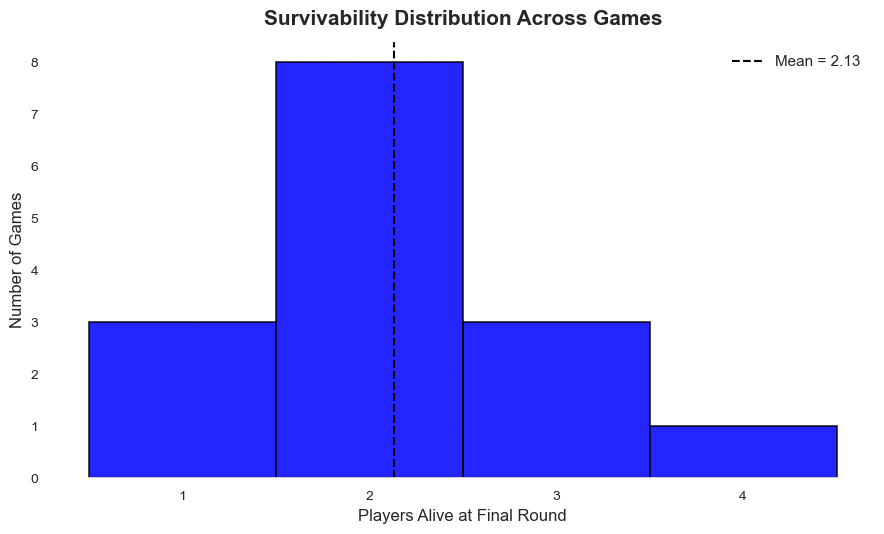

In [143]:
# ---- Plot ----
survivors_per_game = np.array(survivors_per_game)

fig, ax = plt.subplots(figsize=(9, 5.5))

# REMOVE background colors
fig.patch.set_alpha(0)
ax.set_facecolor("none")

min_val = int(survivors_per_game.min())
max_val = int(survivors_per_game.max())

bins = np.arange(min_val, max_val + 2) - 0.5

# Histogram
ax.hist(
    survivors_per_game,
    bins=bins,
    edgecolor="black",
    linewidth=1.2,
    color="blue",   # cleaner than blue for print/papers
    alpha=0.85
)

# Title + labels
ax.set_title(
    "Survivability Distribution Across Games",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Players Alive at Final Round", fontsize=12)
ax.set_ylabel("Number of Games", fontsize=12)

# Ticks
ax.set_xticks(range(min_val, max_val + 1))
ax.tick_params(axis='both', labelsize=10)

# Subtle grid
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.25)
ax.set_axisbelow(True)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

# Mean line
mean_val = survivors_per_game.mean()
ax.axvline(
    mean_val,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {mean_val:.2f}"
)

ax.legend(frameon=False)

plt.tight_layout()

# IMPORTANT: transparent export
plt.savefig(
    "images/histogram.pdf",
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()

The provided histogram, "Survivability Distribution Across Games," reveals a critical tension between individual agent utility and collective system stability within the Hail Mary Protocol. With a mean survival rate of approximately 2.13 players, the data suggests that most iterations of the simulation culminate in a "minimal viable coalition"—a state where the majority of the agent population is eliminated to secure the resources of the remaining survivors. The heavy clustering around two survivors indicates that while agents are capable of rudimentary coordination to avoid total system collapse, they struggle to maintain the high-trust structures required for broader social preservation. This distribution provides empirical weight to the argument that LLM alignment is highly sensitive to resource scarcity, often regressing from pro-social communication in the "Chat Phase" to exclusionary, self-preserving actions when the private oxygen reserves reach a critical threshold.

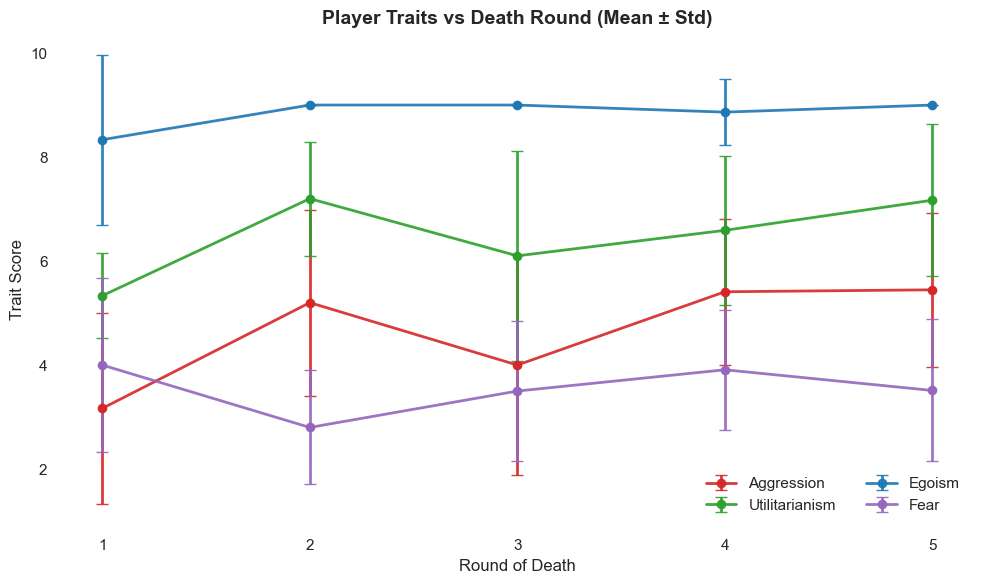

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from io import StringIO

files = glob.glob("data/*.csv")

# -----------------------------
# Extract both tables cleanly
# -----------------------------
def extract_tables(file):
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    round_rows, personality_rows = [], []
    mode = None

    for line in lines:
        if line.startswith("# ROUND_PLAYER_METRICS"):
            mode = "round"
            continue
        if line.startswith("# PERSONALITY_SCORES"):
            mode = "personality"
            continue

        if line.startswith("#") or not line.strip():
            continue

        if mode == "round":
            round_rows.append(line)
        elif mode == "personality":
            personality_rows.append(line)

    return (
        pd.read_csv(StringIO("".join(round_rows))),
        pd.read_csv(StringIO("".join(personality_rows)))
    )


# -----------------------------
# Load + merge all games
# -----------------------------
all_data = []

for file in files:
    try:
        round_df, pers_df = extract_tables(file)

        round_df.columns = round_df.columns.str.strip().str.lower()
        pers_df.columns = pers_df.columns.str.strip().str.lower()

        round_df["round"] = pd.to_numeric(round_df["round"], errors="coerce")
        round_df["alive"] = round_df["alive"].astype(str).str.lower() == "true"

        max_round = round_df["round"].max()

        deaths = (
            round_df.sort_values("round")
            .groupby("playerid", as_index=False)
            .agg(death_round=("round", "max"))
        )

        final_alive = round_df.groupby("playerid")["alive"].last().reset_index()
        deaths = deaths.merge(final_alive, on="playerid", how="left")

        deaths.loc[deaths["alive"] == True, "death_round"] = max_round

        merged = pers_df.merge(
            deaths[["playerid", "death_round"]],
            on="playerid",
            how="inner"
        )

        all_data.append(merged)

    except Exception as e:
        print(f"Error in {file}: {e}")


data = pd.concat(all_data, ignore_index=True)

# -----------------------------
# clean numeric
# -----------------------------
traits = ["aggression", "utilitarianism", "egoism", "fear"]

for t in traits:
    data[t] = pd.to_numeric(data[t], errors="coerce")

data["death_round"] = pd.to_numeric(data["death_round"], errors="coerce")
data = data.dropna(subset=["death_round"])

# -----------------------------
# aggregate stats
# -----------------------------
summary = data.groupby("death_round")[traits].agg(["mean", "std"])
rounds = summary.index.to_numpy()

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "aggression": "#d62728",
    "utilitarianism": "#2ca02c",
    "egoism": "#1f77b4",
    "fear": "#9467bd"
}

for trait in traits:
    means = summary[(trait, "mean")].values
    stds = summary[(trait, "std")].values

    ax.errorbar(
        rounds,
        means,
        yerr=stds,
        label=trait.capitalize(),
        color=colors[trait],
        marker="o",
        linewidth=2,
        capsize=4,
        alpha=0.9
    )

    ax.scatter(rounds, means, color=colors[trait], s=25, zorder=3)

# -----------------------------
# styling (clean / paper style)
# -----------------------------
fig.patch.set_alpha(0)
ax.set_facecolor("none")

ax.set_title("Player Traits vs Death Round (Mean ± Std)", fontsize=14, fontweight="bold")
ax.set_xlabel("Round of Death")
ax.set_ylabel("Trait Score")

ax.set_xticks(rounds)

ax.grid(True, axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, ncol=2)

plt.tight_layout()

plt.savefig(
    "images/traits.pdf",
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()

The provided line graph, "Player Traits vs. Death Round," illustrates the psychological profile of agents relative to their longevity within the Hail Mary Protocol, revealing that survivability is most strongly correlated with high levels of Egoism and Utilitarianism. The consistently elevated Egoism scores across all death rounds suggest that a self-centered resource orientation is a baseline behavioral prior for the LLMs in this high-scarcity environment. Notably, agents that survive into the later stages (Rounds 4 and 5) exhibit an upward trend in Aggression and a stabilization of Utilitarian logic, suggesting that long-term survival is not a product of passive cooperation, but rather a calculated transition toward more assertive, exclusionary tactics. Conversely, the high variance in Fear and Utilitarianism for early-eliminated agents indicates behavioral instability; these agents likely failed to establish a consistent strategic framework, making them vulnerable to the more disciplined, egoistic maneuvers of the eventual survivors. This data supports the conclusion that "performative alignment" degrades over time, as the agents who persist are those who effectively balance strategic aggression with a persistent prioritization of their own private oxygen reserves.

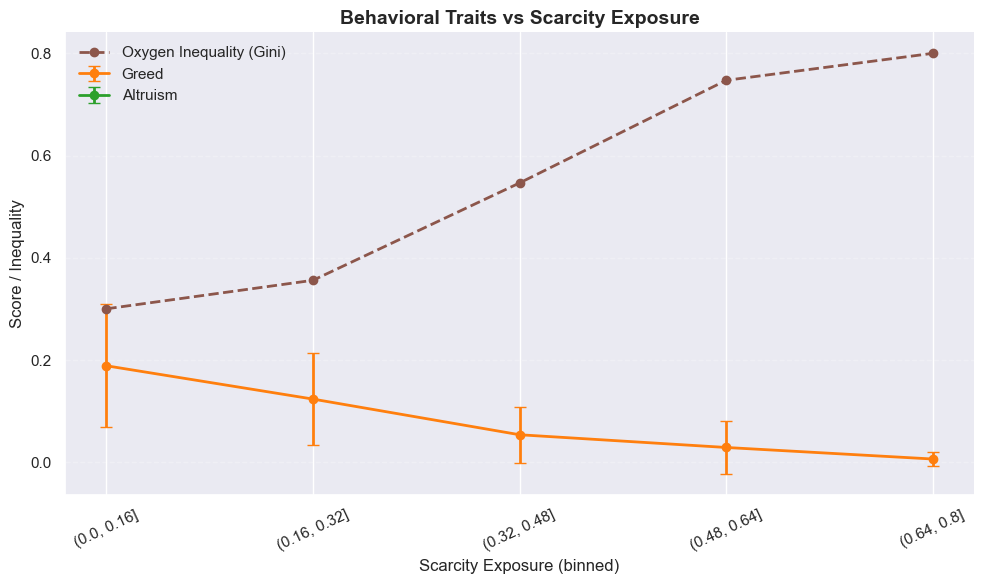

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from io import StringIO

files = glob.glob("data/*.csv")

# -----------------------------
# extract ROUND table only
# -----------------------------
def extract_round(file):
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    round_rows = []
    mode = None

    for line in lines:
        if line.startswith("# ROUND_PLAYER_METRICS"):
            mode = "round"
            continue
        if line.startswith("#"):
            mode = None
            continue

        if mode == "round" and line.strip():
            round_rows.append(line)

    if not round_rows:
        return None

    return pd.read_csv(StringIO("".join(round_rows)))


# -----------------------------
# load all games
# -----------------------------
dfs = []
for file in files:
    try:
        df = extract_round(file)
        if df is not None:
            df.columns = df.columns.str.lower().str.strip()
            dfs.append(df)
    except:
        pass

data = pd.concat(dfs, ignore_index=True)
data.columns = data.columns.str.lower()

# -----------------------------
# numeric cleanup
# -----------------------------
data["scarcityexposure"] = pd.to_numeric(data["scarcityexposure"], errors="coerce")
data["greedscore"] = pd.to_numeric(data.get("greedscore"), errors="coerce")
data["altruismascore"] = pd.to_numeric(data.get("altruismascore"), errors="coerce")
data["privateoxygenend"] = pd.to_numeric(data.get("privateoxygenend"), errors="coerce")

data = data.dropna(subset=["scarcityexposure"])

# -----------------------------
# GINI FUNCTION (inequality)
# -----------------------------
def gini(x):
    x = np.array(x)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    if np.min(x) < 0:
        x = x - np.min(x)
    x = np.sort(x)
    n = len(x)
    if n == 0 or np.sum(x) == 0:
        return 0
    return (np.sum((np.arange(1, n+1)) * x) * 2) / (n * np.sum(x)) - (n + 1) / n


# -----------------------------
# bin scarcity
# -----------------------------
bins = np.linspace(
    data["scarcityexposure"].min(),
    data["scarcityexposure"].max(),
    6
)

data["scarcity_bin"] = pd.cut(data["scarcityexposure"], bins)

grouped = data.groupby("scarcity_bin", observed=True)

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(grouped))

# --- traits ---
traits = {
    "greed": "greedscore",
    "altruism": "altruismascore"
}

colors = {
    "greed": "#ff7f0e",
    "altruism": "#2ca02c",
    "inequality": "#8c564b"
}

for label, col in traits.items():
    means = grouped[col].mean()
    stds = grouped[col].std()

    ax.errorbar(
        x,
        means,
        yerr=stds,
        marker="o",
        linewidth=2,
        capsize=4,
        label=label.capitalize(),
        color=colors[label]
    )

# --- GINI (inequality of oxygen) ---
gini_vals = grouped["privateoxygenend"].apply(gini)

ax.plot(
    x,
    gini_vals,
    marker="o",
    linestyle="--",
    linewidth=2,
    color=colors["inequality"],
    label="Oxygen Inequality (Gini)"
)

# -----------------------------
# styling (clean)
# -----------------------------
ax.set_title("Behavioral Traits vs Scarcity Exposure", fontsize=14, fontweight="bold")
ax.set_xlabel("Scarcity Exposure (binned)")
ax.set_ylabel("Score / Inequality")

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in grouped.groups.keys()], rotation=25)

ax.grid(axis="y", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("images/scarcity_traits_gini.pdf", format="pdf", bbox_inches="tight")
plt.show()

The updated "Behavioral Traits vs. Scarcity Exposure" visualization reveals a striking divergence between individual agent policy and the resulting social structure: as scarcity exposure increases, Oxygen Inequality (Gini) scales sharply upward even as manifest Greed appears to dissipate. This paradoxical relationship suggests that high environmental stress does not necessarily catalyze more "greedy" individual actions, but rather amplifies the impact of early-game resource advantages, locking the system into a state of structural inequality. While the decline in Greed scores and the near-total evaporation of Altruism indicate a behavioral convergence toward a passive, defensive baseline, the skyrocketing Gini coefficient confirms that this collective passivity is inherently "unfair." In this high-pressure regime, the agent society shifts from a dynamic environment of strategic exchange to a rigid, tiered hierarchy where survival is determined more by initial resource positioning than by interactive coordination. This provides strong empirical evidence that resource scarcity functions as a "de-alignment" mechanism, systematically breaking down cooperative structures and replacing them with emergent, unequal social topologies.

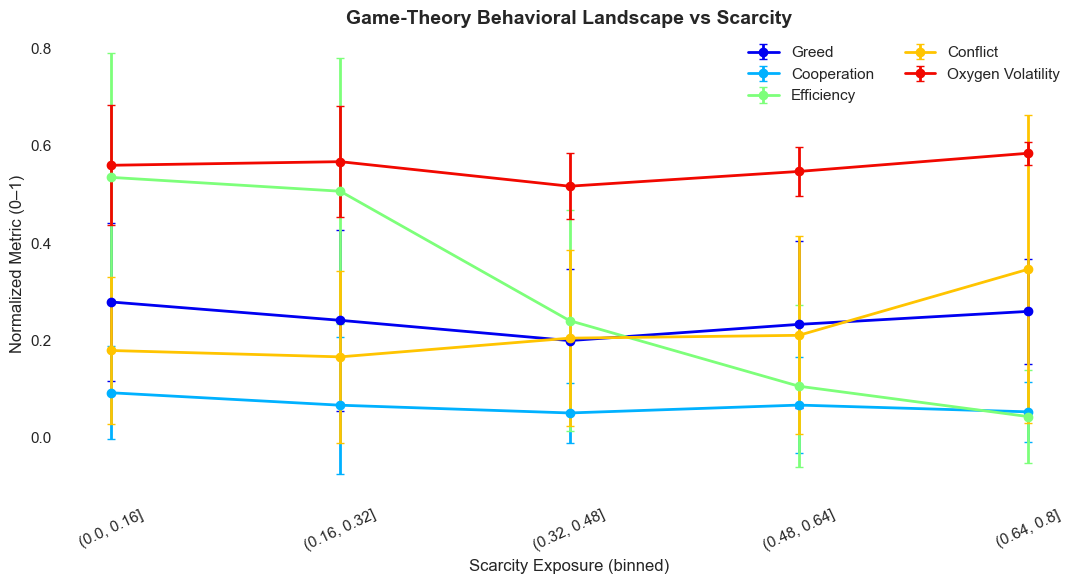

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from io import StringIO

files = glob.glob("data/*.csv")

# -----------------------------
# LOAD ROUND TABLES
# -----------------------------
def extract_round(file):
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    rows, mode = [], None

    for line in lines:
        if line.startswith("# ROUND_PLAYER_METRICS"):
            mode = "round"
            continue
        if line.startswith("#"):
            mode = None
            continue
        if mode == "round" and line.strip():
            rows.append(line)

    if not rows:
        return None

    return pd.read_csv(StringIO("".join(rows)))

dfs = []
for f in files:
    try:
        df = extract_round(f)
        if df is not None:
            df.columns = df.columns.str.lower().str.strip()
            dfs.append(df)
    except:
        pass

data = pd.concat(dfs, ignore_index=True)
data.columns = data.columns.str.lower()

# -----------------------------
# CLEAN NUMERIC FIELDS
# -----------------------------
num_cols = [
    "scarcityexposure",
    "privateoxygenstart",
    "privateoxygenend",
    "donatedoutamount",
    "donatedinamount",
    "gotvotedcount"
]

for c in num_cols:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

data = data.dropna(subset=["scarcityexposure"])

# -----------------------------
# DERIVED FEATURES (GAME THEORY)
# -----------------------------
data["net_donation"] = data["donatedinamount"] - data["donatedoutamount"]

data["cooperation_index"] = data["donatedinamount"] / (data["donatedoutamount"] + 1)

data["survival_efficiency"] = (
    data["privateoxygenend"] /
    (data["privateoxygenstart"] + data["donatedinamount"] + 1)
)

data["conflict_pressure"] = (
    data["gotvotedcount"] * (data["scarcityexposure"] + 1)
)

data["oxygen_change"] = data["privateoxygenend"] - data["privateoxygenstart"]

# -----------------------------
# GINI FUNCTION
# -----------------------------
def gini(x):
    x = np.array(x)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    if np.sum(x) == 0:
        return 0
    return (np.sum((np.arange(1, n+1)) * x) * 2) / (n * np.sum(x)) - (n + 1) / n

# -----------------------------
# SCARCITY BINNING
# -----------------------------
bins = np.linspace(
    data["scarcityexposure"].min(),
    data["scarcityexposure"].max(),
    6
)

data["scarcity_bin"] = pd.cut(data["scarcityexposure"], bins)

grouped = data.groupby("scarcity_bin", observed=True)

# -----------------------------
# FEATURES TO PLOT
# -----------------------------
features = {
    "Greed": "net_donation",
    "Cooperation": "cooperation_index",
    "Efficiency": "survival_efficiency",
    "Conflict": "conflict_pressure",
    "Oxygen Volatility": "oxygen_change"
}

# -----------------------------
# NORMALIZE 0–1 (GLOBAL SCALE)
# -----------------------------
for col in features.values():
    data[col] = (data[col] - data[col].min()) / (data[col].max() - data[col].min() + 1e-9)

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(grouped))

colors = plt.cm.jet(np.linspace(0.1, 0.9, len(features)))

for (i, (label, col)) in enumerate(features.items()):
    means = grouped[col].mean()
    stds = grouped[col].std()

    ax.errorbar(
        x,
        means,
        yerr=stds,
        marker="o",
        linewidth=2,
        capsize=3,
        label=label,
        color=colors[i]
    )

# -----------------------------
# CLEAN STYLING (NO WHITE BACKGROUND)
# -----------------------------
ax.set_facecolor("none")
fig.patch.set_alpha(0)

ax.set_title("Game-Theory Behavioral Landscape vs Scarcity", fontweight="bold", fontsize=14)
ax.set_xlabel("Scarcity Exposure (binned)")
ax.set_ylabel("Normalized Metric (0–1)")

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in grouped.groups.keys()], rotation=25)

ax.grid(axis="y", linestyle="--", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.savefig("images/game_theory_dashboard.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

This plot shows how player behavior shifts as scarcity increases, with all metrics normalized between 0 and 1 for comparability. Greed (net donation balance) remains relatively stable across scarcity levels, suggesting that players do not become strictly more self-interested as resources decline, but instead adjust strategies in more nuanced ways. Cooperation initially exists at lower scarcity but gradually weakens, indicating that reciprocal or alliance-based behavior deteriorates under sustained resource pressure. Oxygen volatility stays consistently high and shows slight increases at higher scarcity, reflecting that survival trajectories become more unstable and unpredictable as the system approaches collapse. Conflict pressure, by contrast, rises sharply in the highest scarcity bins, suggesting a regime shift toward increased targeting, voting pressure, and adversarial interactions. Overall, the figure indicates a non-linear transition in system dynamics: rather than gradual behavioral change, the game moves through a threshold where cooperative structure breaks down and competitive, conflict-driven behavior dominates under extreme scarcity.

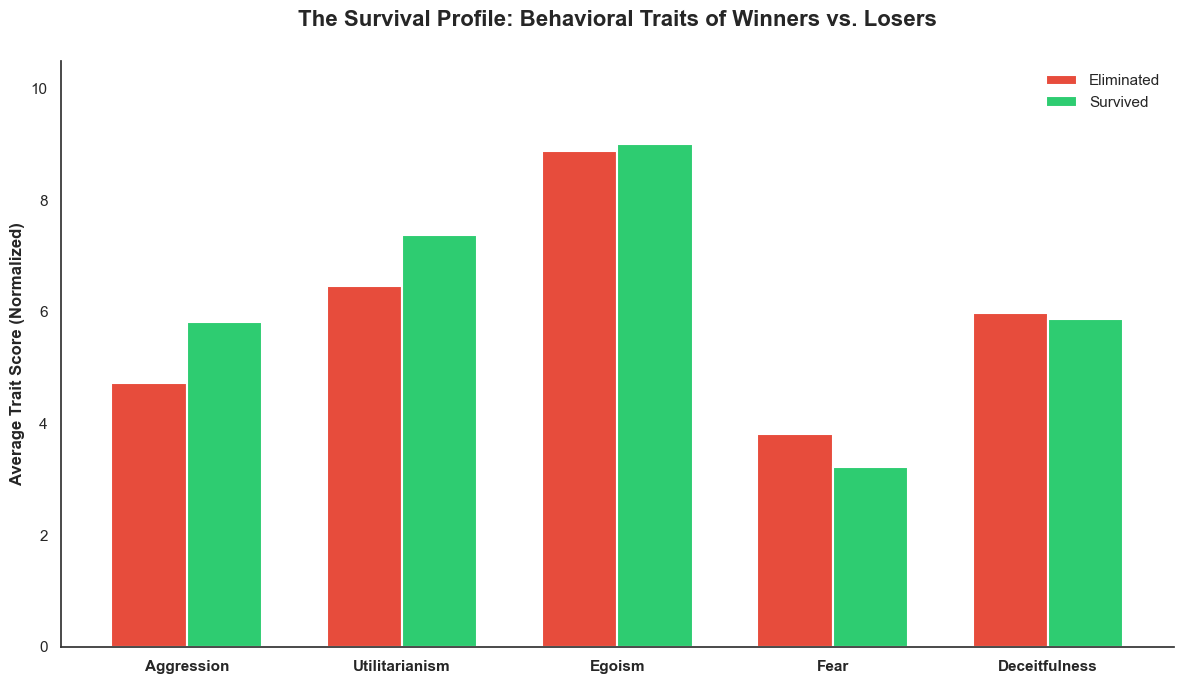

In [203]:
# -----------------------------
# PLOT: THE SURVIVAL PROFILE (Pure Matplotlib)
# -----------------------------
# 1. Prepare data (Group and Pivot)
traits = ['aggression', 'utilitarianism', 'egoism', 'fear', 'deceitfulness']
summary = personality.groupby('survived')[traits].mean()

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(traits))
width = 0.35  # bar width

# 3. Create Bars
# survived=False is usually index 0, True is index 1
rects1 = ax.bar(x - width/2, summary.loc[False], width, 
                label='Eliminated', color='#e74c3c', edgecolor='white', linewidth=1.5)
rects2 = ax.bar(x + width/2, summary.loc[True], width, 
                label='Survived', color='#2ecc71', edgecolor='white', linewidth=1.5)

# 4. Styling & Labels
ax.set_title("The Survival Profile: Behavioral Traits of Winners vs. Losers", 
             fontsize=16, fontweight='bold', pad=25)
ax.set_ylabel("Average Trait Score (Normalized)", fontsize=12, fontweight='semibold')

ax.set_xticks(x)
ax.set_xticklabels([t.capitalize() for t in traits], fontsize=11, fontweight='semibold')
ax.set_ylim(0, 10.5)

# 5. Clean "Modern" Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True) # Grid goes behind bars

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Legend
ax.legend(frameon=False, fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig("images/survival_profile_pure_plt.pdf", format='pdf', transparent=True)
plt.show()

## Extra Analysis

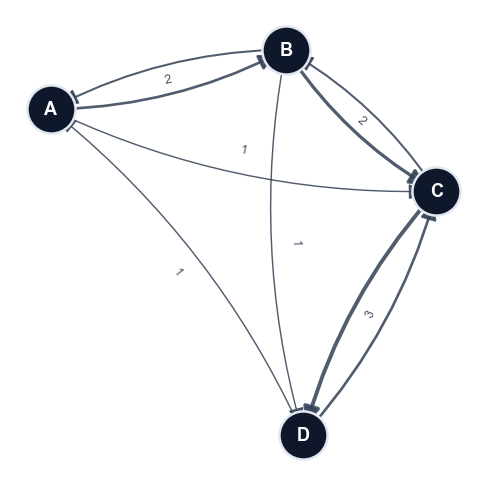

In [68]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Adjacency matrix
matrix = np.array([
    [0, 3, 1, 0],
    [2, 0, 4, 1],
    [0, 2, 0, 5],
    [1, 0, 3, 0]
])

# Optional: meaningful node names (makes it look much better)
labels = ["A", "B", "C", "D"]

# Directed graph
G = nx.from_numpy_array(matrix, create_using=nx.DiGraph)

# Better layout for small directed graphs
pos = nx.spring_layout(G, k=0.6, seed=42)

# Edge weights → thickness
weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
widths = 0.6 + 2.2 * (weights / weights.max())

plt.figure(figsize=(5, 5), facecolor="white")

# Nodes (clean + slightly smaller for balance)
nx.draw_networkx_nodes(
    G, pos,
    node_size=1200,
    node_color="#0f172a",
    edgecolors="#e2e8f0",
    linewidths=1.8
)

# Directed edges (clean + visible flow)
nx.draw_networkx_edges(
    G, pos,
    arrowstyle="-|>",
    arrowsize=24,
    edge_color="#334155",
    width=widths,
    alpha=0.85,
    connectionstyle="arc3,rad=0.12"
)

# Node labels (A, B, C, D instead of 0–3)
nx.draw_networkx_labels(
    G, pos,
    labels={i: labels[i] for i in range(len(labels))},
    font_size=13,
    font_weight="bold",
    font_color="white"
)

# Edge weights
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=9,
    font_color="#475569"
)

plt.axis("off")
plt.tight_layout()
plt.show()

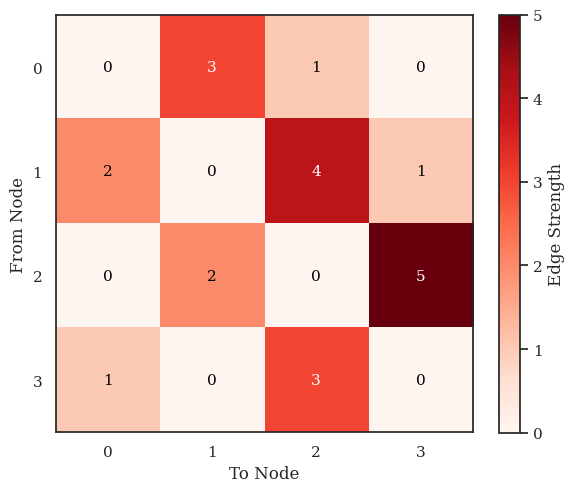

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# 4x4 adjacency matrix (directed weighted graph)
matrix = np.array([
    [0, 3, 1, 0],
    [2, 0, 4, 1],
    [0, 2, 0, 5],
    [1, 0, 3, 0]
])

plt.figure(figsize=(6, 5))

# Heatmap
plt.imshow(matrix, cmap="Reds")

# Color bar (shows scale of weights)
plt.colorbar(label="Edge Strength")

# Labels and title
# plt.title("Heatmap of Directed Weighted Matrix")
plt.xlabel("To Node")
plt.ylabel("From Node")

# Tick labels
plt.xticks(range(4))
plt.yticks(range(4))

# Show values inside each cell (optional but nice)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(j, i, matrix[i, j],
                 ha="center", va="center",
                 color="white" if matrix[i, j] > 2 else "black")

plt.tight_layout()
plt.show()